# Segmentation d'images avec Keras

In [1]:
import math
import random

import matplotlib.pyplot as plt
import numpy
import pandas
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tifffile import imread

## Version courte

Lors de la dernière exécution complète sur un GPU T4 de Colab, cloner les données (8,5 Go) prenait 4 minutes et entraîner le premier modèle 25 minutes. Le U-Net pré-entraîné s'entraîne ensuite sur autant d'epochs. Pour une démonstration en direct, passez `SHORT_RUN` à `True` dans la cellule suivante :

- un quart des tuiles d'entraînement (environ 320 au lieu de 1 296), prises dans chacune des 16 zones ;
- 3 epochs au lieu de 15 pour chacun des deux modèles.

Comptez alors une dizaine de minutes sur un T4 (mesuré : 5 à 6 minutes pour les deux entraînements, plus le clonage des données), pour des scores plus bas, surtout celui du premier modèle, entraîné de zéro.

In [2]:
# Passez à True pour la version courte (voir ci-dessus)
SHORT_RUN = False

# Part des tuiles d'entraînement utilisées (1.0 : toutes)
TRAIN_FRACTION = 0.25 if SHORT_RUN else 1.0
# Nombre d'epochs de chaque modèle
EPOCHS = 3 if SHORT_RUN else 15

In [3]:
!nvidia-smi

Wed Oct  7 11:23:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:04:00.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
%%time
!rm -rf sample_data
!git clone https://github.com/mlambda/ign-FNF-2009.git

Cloning into 'ign-FNF-2009'...
remote: Enumerating objects: 4604, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4604 (delta 4), reused 8 (delta 2), pack-reused 4594 (from 1)
Receiving objects: 100% (4604/4604), 3.93 GiB | 5.78 MiB/s, done.
Resolving deltas: 100% (2894/2894), done.
Updating files: 100% (4869/4869), done.
CPU times: user 1.63 s, sys: 348 ms, total: 1.98 s
Wall time: 12min 19s


## Chargement des données

Les données sont des photographies aériennes prises par l'IGN en 2009 en Lorraine : 20 zones de 5 km × 5 km. Chaque zone est découpée en 9 × 9 = 81 tuiles de 1024 × 1024 pixels (1 pixel = 50 cm sur le terrain : une tuile couvre 512 m × 512 m).

- **Entrée** (fichiers `*_irc.tif`) : une image en *infrarouge couleur* (IRC). Ses trois canaux sont le proche infrarouge, le rouge et le vert, affichés en rouge, vert et bleu. La végétation réfléchit fortement l'infrarouge : elle apparaît en rouge.
- **Cible** (fichiers `*_pfnf_nch.tif`) : la classe de chaque pixel, forêt ou non-forêt, codée en *one-hot* sur deux canaux. Le code en garde l'indice : 1 pour forêt, 0 pour non-forêt. Au sens de l'IGN, une forêt n'est pas un simple groupe d'arbres : c'est une surface de plus de 5 000 m², large d'au moins 20 m, dont la végétation couvre au moins 10 % du sol et qui n'est pas utilisée pour l'agriculture.

2 zones ont été mises de côté pour la validation, et 2 autres pour le test. Toutes les tuiles d'une zone vont dans le même ensemble : des tuiles voisines se ressemblent trop pour mesurer honnêtement la généralisation.

In [5]:
df_train = pandas.read_csv("ign-FNF-2009/train-files.csv")
df_val = pandas.read_csv("ign-FNF-2009/val-files.csv")
df_test = pandas.read_csv("ign-FNF-2009/test-files.csv")

if TRAIN_FRACTION < 1:
  # Version courte : une partie des tuiles de chaque zone d'entraînement
  df_train = (
    df_train.groupby("coord")
    .sample(frac=TRAIN_FRACTION, random_state=0)
    .reset_index(drop=True)
  )

print("Coordonnées en entraînement")
print(df_train.coord.unique())

print("Coordonnées en val")
print(df_val.coord.unique())

print("Coordonnées en test")
print(df_test.coord.unique())

df_test

Coordonnées en entraînement
['945_6845' '980_6825' '945_6925' '955_6915' '915_6825' '975_6850'
 '940_6905' '995_6895' '940_6925' '915_6890' '1015_6895' '920_6860'
 '890_6940' '975_6835' '975_6825' '925_6860']
Coordonnées en val
['970_6845' '910_6935']
Coordonnées en test
['915_6915' '995_6850']


,Unnamed: 0,Observations,Annotations,latitude,longitude,ligne,colonne,coord
0,0,ign-FNF-2009/test/observations/915_6915_8_2_ob...,ign-FNF-2009/test/annotations/915_6915_8_2_0M5...,915,6915,8,2,915_6915
1,1,ign-FNF-2009/test/observations/995_6850_5_4_ob...,ign-FNF-2009/test/annotations/995_6850_5_4_0M5...,995,6850,5,4,995_6850
2,2,ign-FNF-2009/test/observations/915_6915_4_9_ob...,ign-FNF-2009/test/annotations/915_6915_4_9_0M5...,915,6915,4,9,915_6915
3,3,ign-FNF-2009/test/observations/915_6915_5_4_ob...,ign-FNF-2009/test/annotations/915_6915_5_4_0M5...,915,6915,5,4,915_6915
4,4,ign-FNF-2009/test/observations/995_6850_8_6_ob...,ign-FNF-2009/test/annotations/995_6850_8_6_0M5...,995,6850,8,6,995_6850
...,...,...,...,...,...,...,...,...
155,155,ign-FNF-2009/test/observations/995_6850_9_1_ob...,ign-FNF-2009/test/annotations/995_6850_9_1_0M5...,995,6850,9,1,995_6850
156,156,ign-FNF-2009/test/observations/995_6850_5_8_ob...,ign-FNF-2009/test/annotations/995_6850_5_8_0M5...,995,6850,5,8,995_6850
157,157,ign-FNF-2009/test/observations/995_6850_3_6_ob...,ign-FNF-2009/test/annotations/995_6850_3_6_0M5...,995,6850,3,6,995_6850
158,158,ign-FNF-2009/test/observations/995_6850_4_4_ob...,ign-FNF-2009/test/annotations/995_6850_4_4_0M5...,995,6850,4,4,995_6850


## Étude d'un exemple et de son annotation

L'entrée est en fausses couleurs : la végétation y apparaît en rouge. Dans la cible, la forêt est en jaune et le reste en violet.

In [6]:
example_input = imread(df_train.Observations[0])
example_annotation = imread(df_train.Annotations[0])

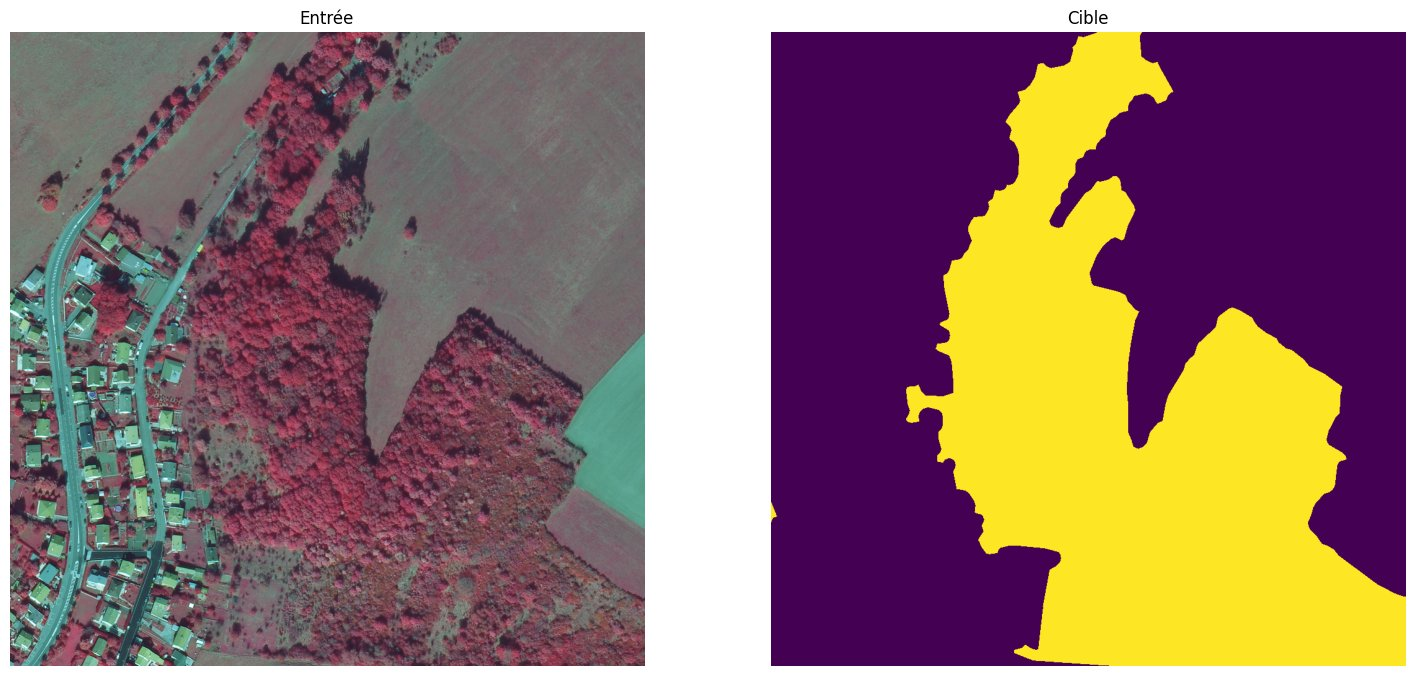

In [7]:
def display_sample(*images: numpy.array) -> None:
  """Show side-by-side an input image, the ground truth and the prediction."""
  figure, axes = plt.subplots(1, len(images), figsize=(18, 18))

  titles = ["Entrée", "Cible", "Prédiction"]
  for image, ax, title in zip(images, axes, titles):
    ax.set_title(title)
    if image.ndim == 3 and image.shape[2] == 3:
      # Image en infrarouge couleur
      ax.imshow(image)
    else:
      if image.ndim == 3:
        # Canal de la classe forêt (le dernier)
        image = image[..., -1]
      # Bornes fixes : forêt (1) en jaune, non-forêt (0) en violet, même quand
      # toute la tuile est d'une seule classe
      ax.imshow(image, vmin=0, vmax=1)
    ax.axis("off")
  plt.show()


display_sample(example_input, example_annotation)

## Options générales

In [8]:
# Dimension des images originales
dim_original = 1024

# Dimension des images en entrée du réseau
dim_input = 512

# Nombre de canaux des images en entrée
num_channel = 3

## Augmentation des données

En traitement d'images, il est extrêmement important d'augmenter les données par des transformations pour rendre le réseau appris moins sensibles aux rotations, recadrages, etc. La fonction `transform_data`, si `eval` vaut `True` se contentera de faire un recadrage centré des images `X` et `Y`, et sinon fera toutes les transformations opportunes sur ces mêmes tableaux pour l'entraînement (recadrage aléatoire, miroir, rotation, etc).

Elle utilise les fonctions du module [`tf.image`](https://www.tensorflow.org/api_docs/python/tf/image/).

In [9]:
def transform_data(
  X: numpy.ndarray,
  Y: numpy.ndarray,
  eval: bool = False,
  cropped_size: tuple[int, int] = (dim_input, dim_input),
) -> tuple[numpy.ndarray, numpy.ndarray]:
  height, width = X.shape[:2]
  cropped_height, cropped_width = cropped_size
  if eval:
    # Recadrage centré
    crop_params = dict(
      offset_height=(height - cropped_height) // 2,
      offset_width=(width - cropped_width) // 2,
      target_height=cropped_height,
      target_width=cropped_width,
    )
    X = tf.image.crop_to_bounding_box(X, **crop_params)
    Y = tf.image.crop_to_bounding_box(Y, **crop_params)
  else:
    # Rotation aléatoire
    k = random.choice([None, 1, 3])
    if k is not None:
      X = tf.image.rot90(X, k)
      Y = tf.image.rot90(Y, k)

    # Recadrage aléatoire
    crop_params = dict(
      offset_height=random.randint(0, height - cropped_height),
      offset_width=random.randint(0, width - cropped_width),
      target_height=cropped_height,
      target_width=cropped_width,
    )
    X = tf.image.crop_to_bounding_box(X, **crop_params)
    Y = tf.image.crop_to_bounding_box(Y, **crop_params)

    # Miroir horizontal
    if random.random() > 0.5:
      X = tf.image.flip_left_right(X)
      Y = tf.image.flip_left_right(Y)

    # Miroir vertical
    if random.random() > 0.5:
      X = tf.image.flip_up_down(X)
      Y = tf.image.flip_up_down(Y)
  return X, Y

## Création d'un générateur Keras

Pour définir un générateur Keras, nous allons utiliser la classe [`keras.utils.Sequence`](https://www.tensorflow.org/api_docs/python/tf/keras/utils/Sequence). Pour ce faire, Il faut principalement deux méthodes : `__getitem__`, qui est appelée à chaque itération pour récupérer le batch à traiter, et `__len__`, qui est appelée pour connaître le nombre total de batchs qui sera fourni par le générateur. Nous utiliserons aussi `on_epoch_end` pour mélanger le dataset avant l'itération suivante.

In [10]:
class DataGenerator(keras.utils.Sequence):
  """Generate data for Keras."""

  def __init__(
    self,
    df: pandas.DataFrame,
    batch_size: int,
    eval: bool,
    cropped_size: tuple[int, int] = (dim_input, dim_input),
  ) -> None:
    """Initialize the generator."""
    self.X_paths = df.Observations
    self.Y_paths = df.Annotations
    assert self.X_paths.shape[0] == self.Y_paths.shape[0]
    self.batch_size = batch_size
    self.eval = eval
    self.cropped_size = cropped_size
    if eval:
      self.indices = numpy.arange(self.X_paths.shape[0])
    else:
      self.indices = numpy.random.permutation(self.X_paths.shape[0])

  def __len__(self):
    """Compute the number of batches per epoch."""
    return int(math.ceil(self.X_paths.shape[0] / self.batch_size))

  def __getitem__(self, index):
    """Generate one batch of data."""
    # Generate indexes of the batch
    start = index * self.batch_size
    Xs = []
    Ys = []
    for i in self.indices[start : start + self.batch_size]:
      X, Y = transform_data(
        imread(self.X_paths[i]),
        imread(self.Y_paths[i]).argmax(axis=-1)[..., numpy.newaxis],
        self.eval,
        self.cropped_size,
      )
      Xs.append(X)
      Ys.append(tf.squeeze(Y))
    return tf.stack(Xs), tf.stack(Ys)

  def on_epoch_end(self):
    """Update indexes after each epoch."""
    if not self.eval:
      self.indices = numpy.random.permutation(self.X_paths.shape[0])


generator = DataGenerator(df_train, 3, True)
X, Y = generator[0]
X.shape, Y.shape

(TensorShape([3, 512, 512, 3]), TensorShape([3, 512, 512]))

## Création du modèle

Pour le modèle, nous devons passer d'une image de dimension (batch × hauteur × largeur × 3) à une sortie de dimension (batch × hauteur × largeur).

Ce premier modèle, repris d'un [exemple Keras](https://keras.io/examples/vision/oxford_pets_image_segmentation/), est un encodeur-décodeur entraîné de zéro. L'encodeur réduit l'image de 512 × 512 à 32 × 32 en extrayant des caractéristiques, puis le décodeur l'agrandit jusqu'à 512 × 512 pour donner à chaque pixel une probabilité d'être de la forêt. Il n'a pas de connexions transversales entre l'encodeur et le décodeur : le décodeur doit reconstruire seul les détails fins perdus pendant la réduction.

In [11]:
# Adaptation directe du modèle
# https://keras.io/examples/vision/oxford_pets_image_segmentation/
# Ce modèle n'a pas les connexions transversales d'un vrai U-Net
# (https://arxiv.org/abs/1505.04597) : la section « U-Net pré-entraîné » plus
# bas en construit un. Un panorama des modèles de segmentation :
# https://arxiv.org/abs/2001.05566
def get_model(
  input_height: int = dim_input, input_width: int = dim_input
) -> keras.Model:
  inputs = keras.Input(shape=(input_height, input_width, num_channel))

  x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.Activation("relu")(x)

  previous_block_activation = x

  for filters in [64, 128, 256]:
    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Activation("relu")(x)
    x = layers.SeparableConv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    residual = layers.Conv2D(filters, 1, strides=2, padding="same")(
      previous_block_activation
    )
    x = layers.add([x, residual])
    previous_block_activation = x

  for filters in [256, 128, 64, 32]:
    x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Activation("relu")(x)
    x = layers.Conv2DTranspose(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)

    x = layers.UpSampling2D(2)(x)

    residual = layers.UpSampling2D(2)(previous_block_activation)
    residual = layers.Conv2D(filters, 1, padding="same")(residual)
    x = layers.add([x, residual])
    previous_block_activation = x

  x = layers.Conv2D(32, 1, activation="relu")(x)
  x = layers.Dropout(0.9)(x)
  outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

  model = keras.Model(inputs, outputs)
  return model

## Entraînement

On peut maintenant utiliser notre classe de génération de données pour entraîner notre modèle.

En plus de l'accuracy, la part des pixels bien classés, on suit l'IoU (*intersection over union*) de la classe forêt : la surface où la prédiction et la cible disent toutes deux « forêt », divisée par la surface où au moins l'une des deux le dit. Elle vaut 1 pour un masque parfait, et 0 pour un modèle qui ne prédit jamais la forêt, quelle que soit son accuracy.

In [12]:
# Construction du modèle
model = get_model()
model.summary()
model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=[
    "accuracy",
    keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name="iou"),
  ],
)

batch_size = 4

# Création des générateurs
train_generator = DataGenerator(df_train, batch_size, eval=False)
val_generator = DataGenerator(df_val, batch_size, eval=True)

# Entraînement du modèle, en évaluation sur le générateur de validation à la fin
# de chaque epoch
model.fit(
  train_generator,
  validation_data=val_generator,
  epochs=EPOCHS,
  callbacks=[
    keras.callbacks.EarlyStopping(patience=5, monitor="val_loss"),
    keras.callbacks.ModelCheckpoint(
      filepath="best_model.weights.h5",
      monitor="val_accuracy",
      mode="max",
      save_weights_only=True,
      save_best_only=True,
    ),
  ],
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ activation[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │      2,400 │ activation_1[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │      4,736 │ activation_2[0][… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 128, 128,  │      8,896 │ activation_3[0][… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 128, 128,  │          0 │ batch_normalizat

 Total params: 2,059,201 (7.86 MB)

 Trainable params: 2,055,425 (7.84 MB)

 Non-trainable params: 3,776 (14.75 KB)

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 174s 366ms/step - accuracy: 0.7803 - iou: 0.6613 - loss: 0.5216 - val_accuracy: 0.6067 - val_iou: 3.8322e-06 - val_loss: 1.2163
Epoch 2/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 133s 286ms/step - accuracy: 0.8258 - iou: 0.7195 - loss: 0.3802 - val_accuracy: 0.9201 - val_iou: 0.8060 - val_loss: 0.2245
Epoch 3/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 101s 310ms/step - accuracy: 0.8399 - iou: 0.7406 - loss: 0.3491 - val_accuracy: 0.9392 - val_iou: 0.8510 - val_loss: 0.2198
Epoch 4/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 93s 285ms/step - accuracy: 0.8512 - iou: 0.7514 - loss: 0.3156 - val_accuracy: 0.9349 - val_iou: 0.8390 - val_loss: 0.2639
Epoch 5/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 93s 287ms/step - accuracy: 0.8612 - iou: 0.7675 - loss: 0.3030 - val_accuracy: 0.9489 - val_iou: 0.8765 - val_loss: 0.1640
Epoch 6/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 98s 303ms/step - accuracy: 0.8613 - iou: 0.7674 - loss: 0.2969 - val_accuracy: 0.9491 - val_iou: 0.8762 - val_loss: 0.2345
Epoch 7/15
324/

## Application aux données de test

20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 223ms/step - accuracy: 0.9772 - iou: 0.9638 - loss: 0.0804
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
(8, 512, 512, 3) (8, 512, 512) (8, 512, 512)


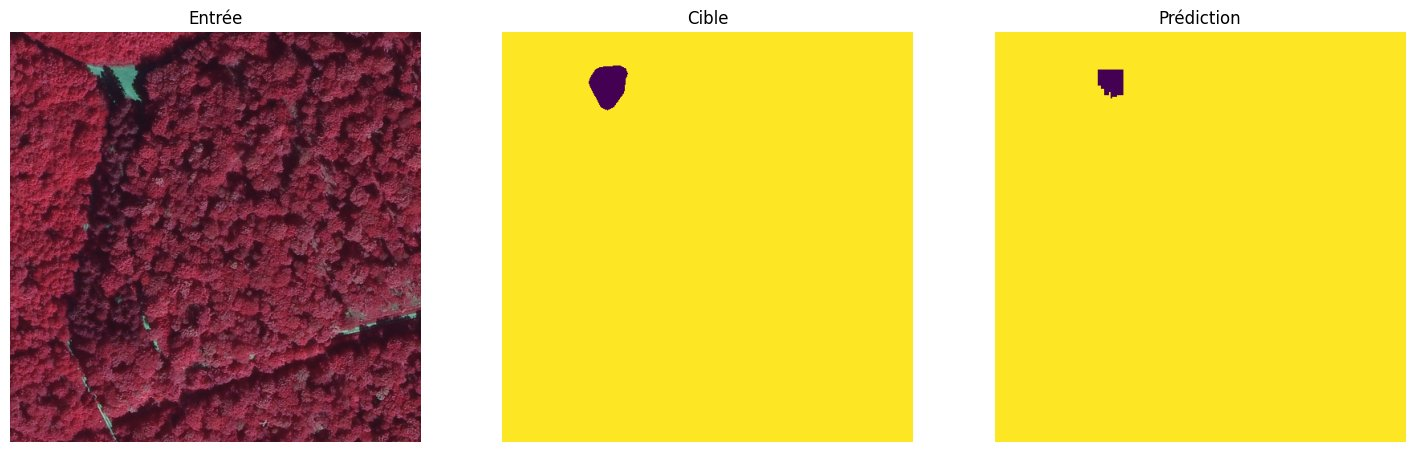

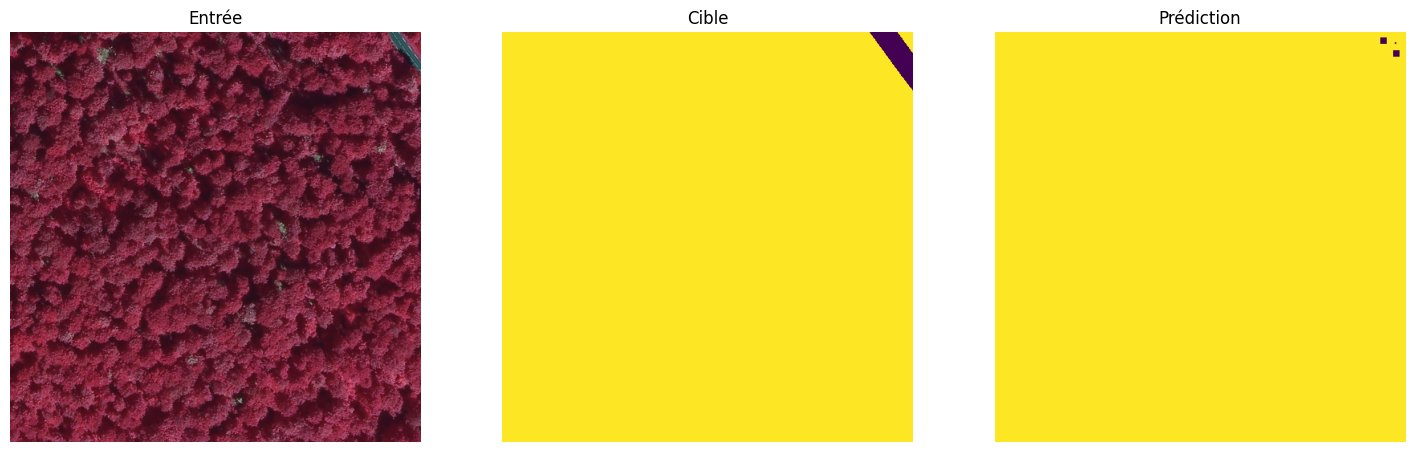

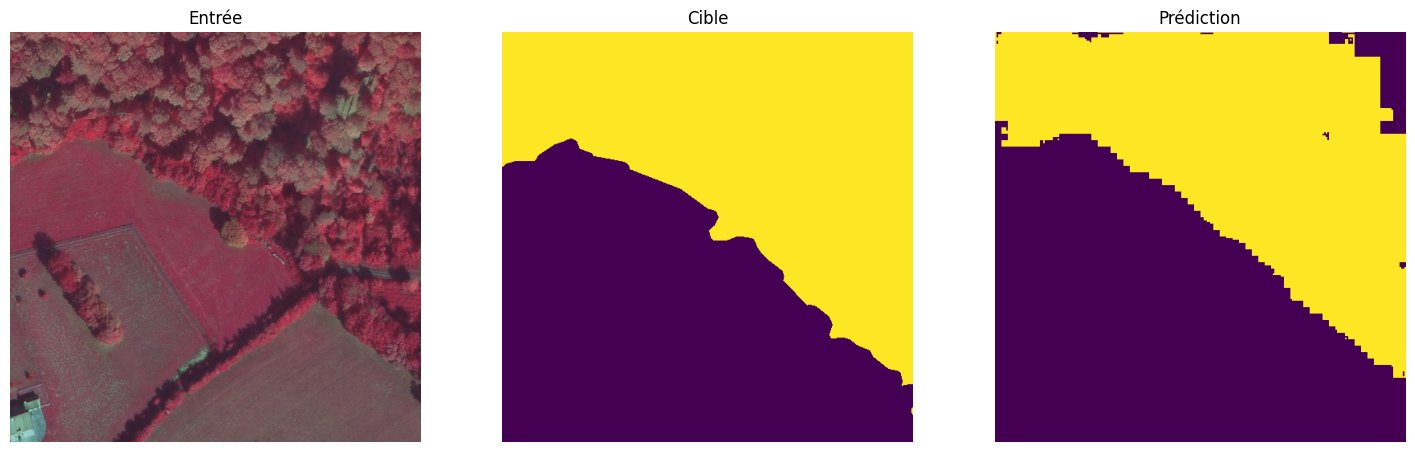

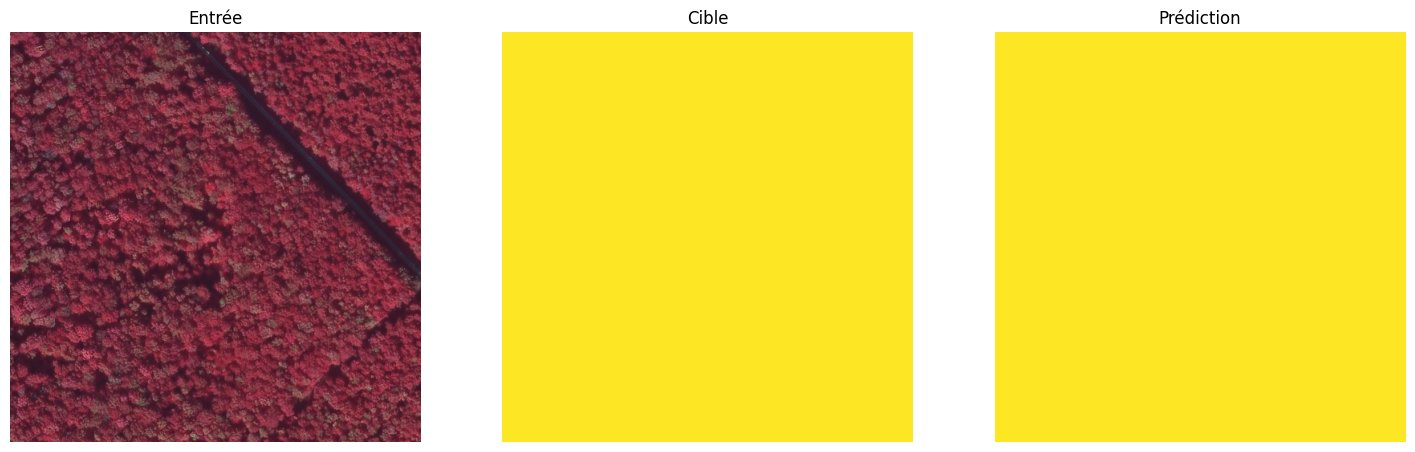

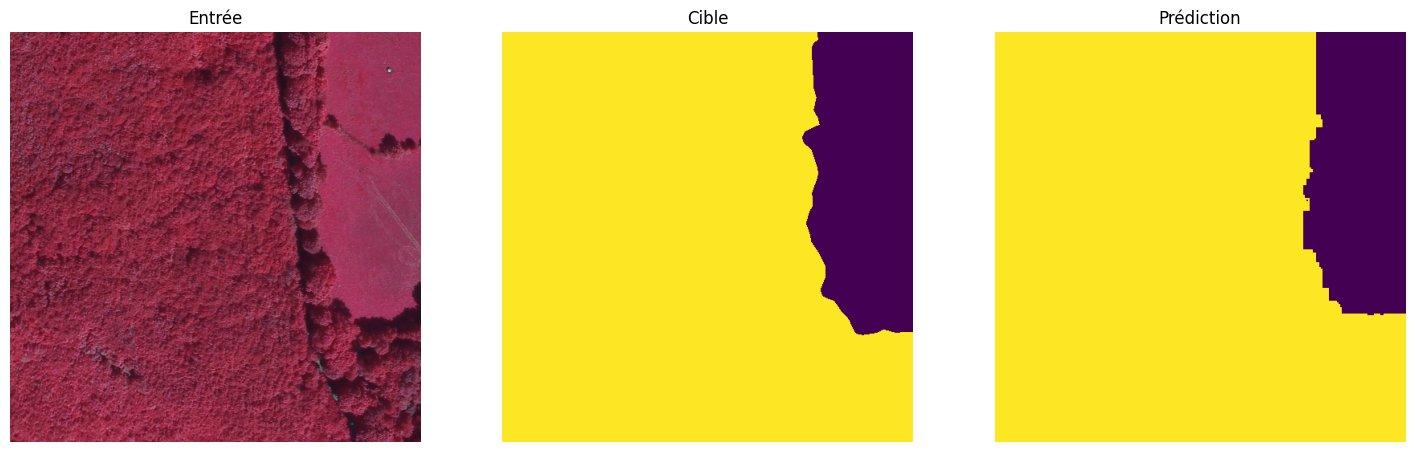

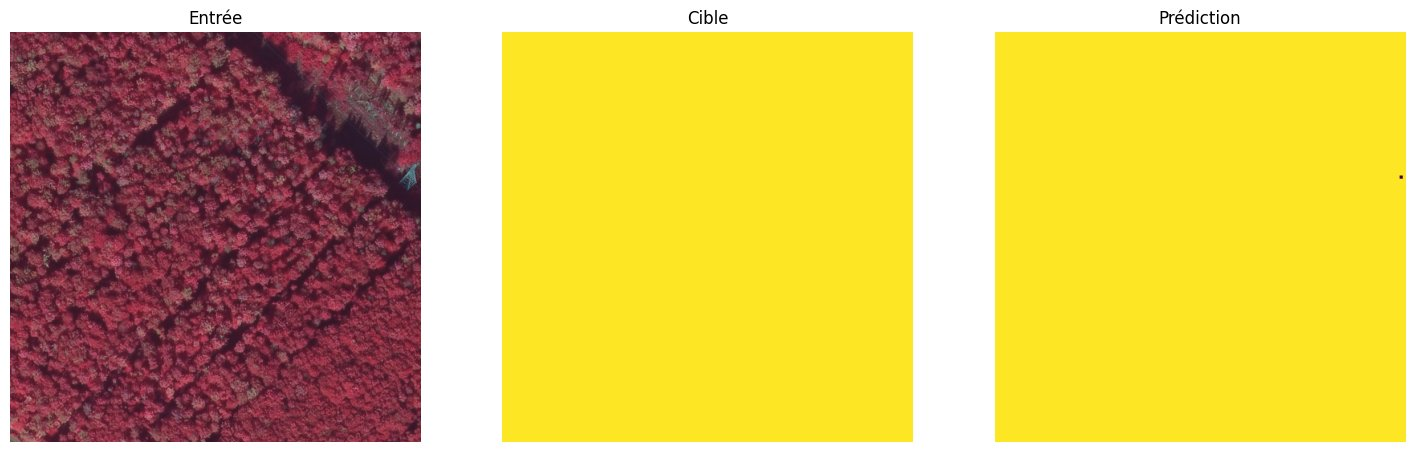

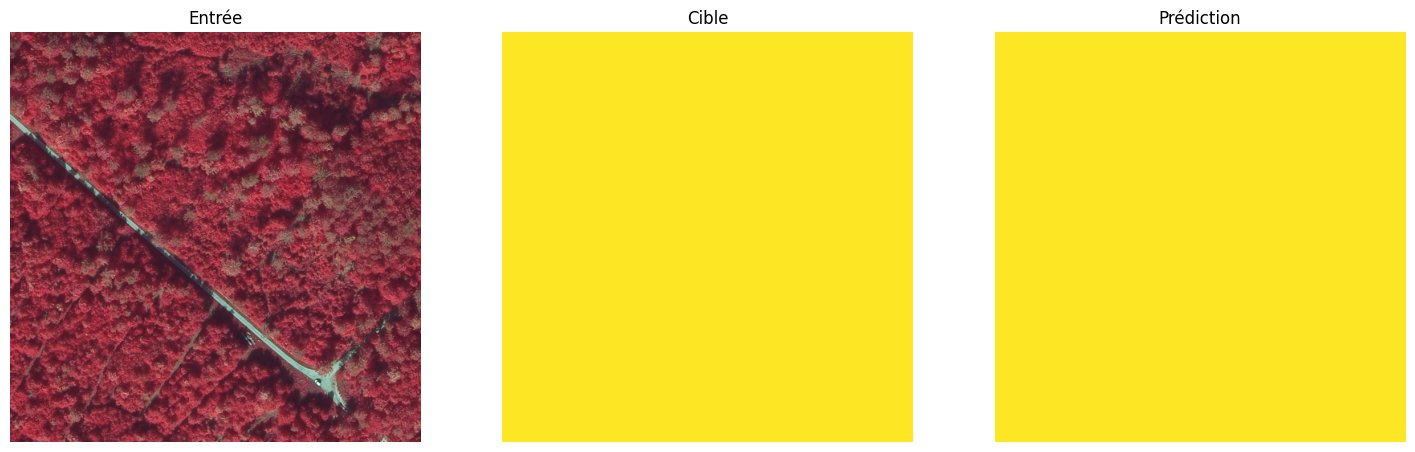

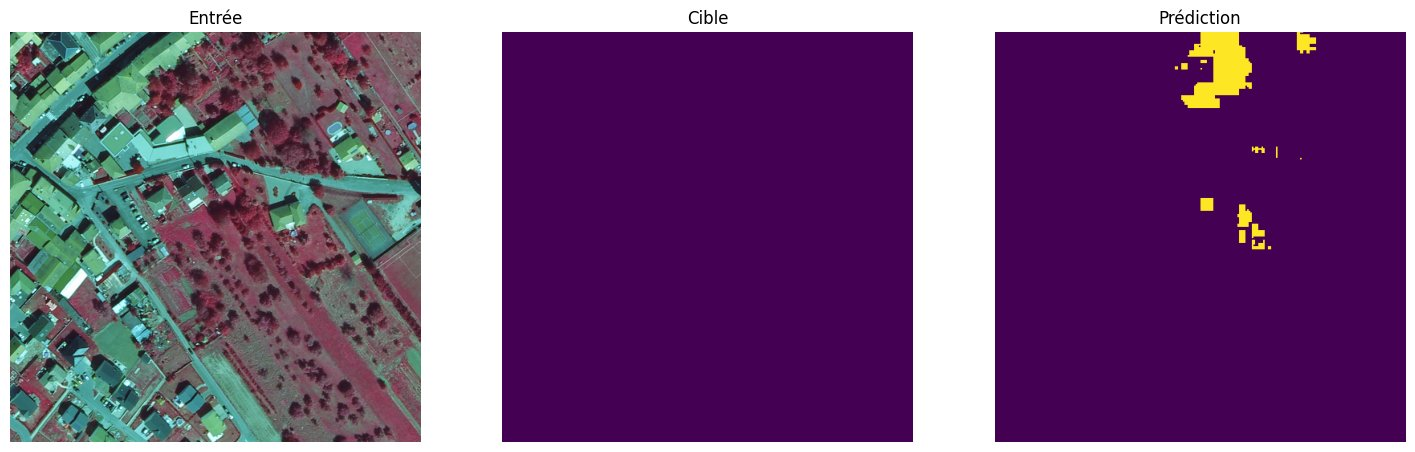

In [13]:
# Chargement du meilleur modèle
model.load_weights("best_model.weights.h5")

# Scores de chaque modèle sur les tuiles de test
test_generator = DataGenerator(df_test, 8, eval=True)
results = {
  "Encodeur-décodeur entraîné de zéro": model.evaluate(
    test_generator, return_dict=True
  )
}

# Prédictions sur 8 tuiles de test : forêt si sa probabilité dépasse le seuil
threshold = 0.5
X, Y = test_generator[6]
preds = (model.predict(X)[..., 0] > threshold).astype("uint8")

print(X.shape, Y.shape, preds.shape)

for x, y, p in zip(X, Y, preds):
  display_sample(x, y, p)

## U-Net pré-entraîné

Le modèle précédent part de zéro, et son décodeur doit reconstruire les contours fins à partir d'une image réduite à 32 × 32. Un [U-Net](https://arxiv.org/abs/1505.04597) répond à ces deux points :

- **un encodeur pré-entraîné** : [MobileNetV2](https://arxiv.org/abs/1801.04381), entraîné à classer les photos d'ImageNet, sait déjà extraire des bords, des textures et des formes. On le gèle (`trainable = False`) : seul le décodeur apprend. ImageNet ne contient pas d'images infrarouges, mais ces caractéristiques visuelles restent utiles ;
- **des connexions transversales** (*skip connections*) : à chaque résolution (256, 128, 64 puis 32 pixels de côté), le décodeur reçoit, en plus de sa propre sortie agrandie, les caractéristiques que l'encodeur a calculées à cette même résolution. Il retrouve ainsi les détails perdus pendant la réduction.

Les données, les augmentations et le nombre d'epochs restent les mêmes que pour le premier modèle.

In [14]:
def get_pretrained_unet(
  input_height: int = dim_input, input_width: int = dim_input
) -> keras.Model:
  # Encodeur : MobileNetV2 pré-entraîné sur ImageNet, sans sa tête de
  # classification. Keras prévient qu'il charge les poids prévus pour des images
  # de 224 × 224 : ses convolutions s'appliquent à toute taille d'image.
  mobilenet = keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(input_height, input_width, num_channel),
  )
  # Sorties de l'encodeur reprises par le décodeur, de la plus fine (256 × 256)
  # à la plus grossière (32 × 32), puis le fond du « U » (16 × 16)
  layer_names = [
    "block_1_expand_relu",
    "block_3_expand_relu",
    "block_6_expand_relu",
    "block_13_expand_relu",
    "block_16_project",
  ]
  encoder = keras.Model(
    mobilenet.input,
    [mobilenet.get_layer(name).output for name in layer_names],
    name="encoder",
  )
  encoder.trainable = False

  inputs = keras.Input(shape=(input_height, input_width, num_channel))
  # MobileNetV2 attend des pixels entre -1 et 1
  x = layers.Rescaling(1 / 127.5, offset=-1)(inputs)
  *skips, x = encoder(x)

  # Décodeur : à chaque étape, on double la résolution et on concatène la sortie
  # de l'encodeur de même résolution (connexion transversale)
  for filters, skip in zip([256, 128, 64, 32], reversed(skips)):
    x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

  # Dernier doublement, jusqu'à la résolution de l'image d'entrée
  x = layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu")(x)
  outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)
  return keras.Model(inputs, outputs, name="unet")

In [15]:
unet = get_pretrained_unet()
unet.summary()
unet.compile(
  # Seul le décodeur, parti de zéro, apprend : un pas d'apprentissage plus grand
  # que pour le premier modèle lui convient
  optimizer=keras.optimizers.Adam(learning_rate=1e-3),
  loss="binary_crossentropy",
  metrics=[
    "accuracy",
    keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name="iou"),
  ],
)

unet.fit(
  train_generator,
  validation_data=val_generator,
  epochs=EPOCHS,
  callbacks=[
    keras.callbacks.EarlyStopping(patience=5, monitor="val_loss"),
    keras.callbacks.ModelCheckpoint(
      filepath="best_unet.weights.h5",
      monitor="val_accuracy",
      mode="max",
      save_weights_only=True,
      save_best_only=True,
    ),
  ],
)

/tmp/ipykernel_3076/1184574275.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 512, 512,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 256, 256, │  1,841,984 │ rescaling[0][0]   │
│ (Functional)        │ 96), (None, 128,  │            │                   │
│                     │ 128, 144), (None, │            │                   │
│                     │ 64, 64, 192),     │            │                   │
│                     │ (None, 32, 32,    │            │                   │
│                     │ 576), (None, 16,  │            │                   │
│                     │ 16, 320)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 32, 32,    │    737,536 │ encoder[0][4]     │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 832)              │            │ encoder[0][3]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │  1,917,184 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_9  │ (None, 64, 64,    │    295,040 │ activation_15[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 320)              │            │ encoder[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 64, 64,    │    368,768 │ concatenate_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_10 │ (None, 128, 128,  │     73,792 │ activation_16[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 208)              │            │ encoder[0][1]   

 Total params: 5,416,097 (20.66 MB)

 Trainable params: 3,573,153 (13.63 MB)

 Non-trainable params: 1,842,944 (7.03 MB)

Epoch 1/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 153s 341ms/step - accuracy: 0.9150 - iou: 0.8350 - loss: 0.2602 - val_accuracy: 0.9176 - val_iou: 0.8231 - val_loss: 0.2138
Epoch 2/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 69s 212ms/step - accuracy: 0.9321 - iou: 0.8656 - loss: 0.2130 - val_accuracy: 0.8206 - val_iou: 0.5464 - val_loss: 0.3573
Epoch 3/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 71s 219ms/step - accuracy: 0.9566 - iou: 0.9108 - loss: 0.1448 - val_accuracy: 0.9493 - val_iou: 0.8752 - val_loss: 0.1426
Epoch 4/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 71s 218ms/step - accuracy: 0.9548 - iou: 0.9076 - loss: 0.1426 - val_accuracy: 0.9472 - val_iou: 0.8677 - val_loss: 0.1734
Epoch 5/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 73s 224ms/step - accuracy: 0.9571 - iou: 0.9117 - loss: 0.1317 - val_accuracy: 0.9508 - val_iou: 0.8835 - val_loss: 0.1298
Epoch 6/15
324/324 ━━━━━━━━━━━━━━━━━━━━ 80s 216ms/step - accuracy: 0.9599 - iou: 0.9180 - loss: 0.1264 - val_accuracy: 0.9566 - val_iou: 0.8932 - val_loss: 0.1338
Epoch 7/15
324/324 ━━

### Application aux données de test

20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 240ms/step - accuracy: 0.9811 - iou: 0.9700 - loss: 0.0671
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


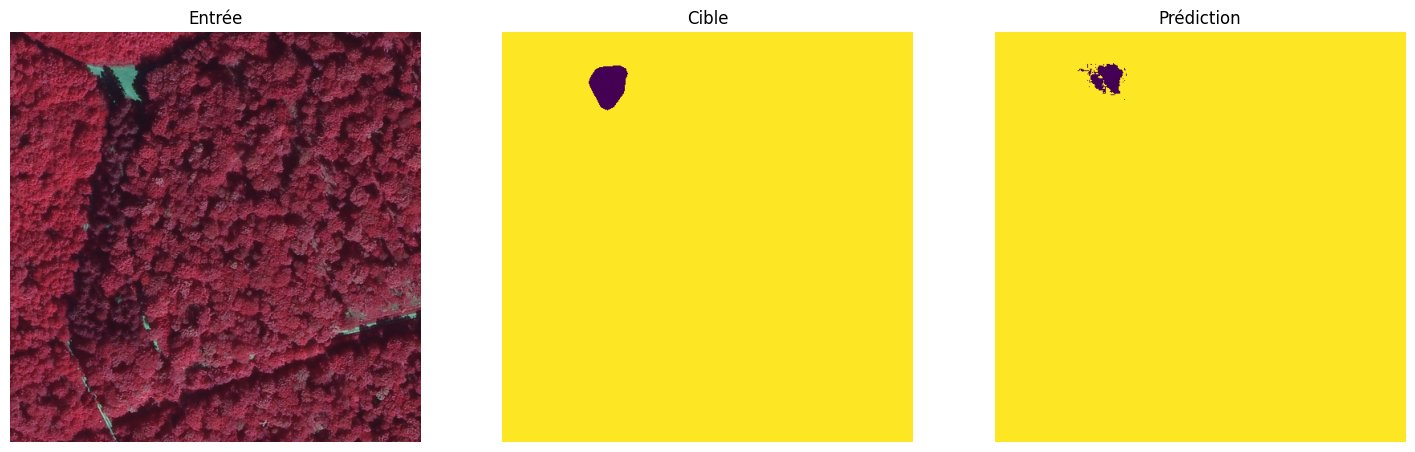

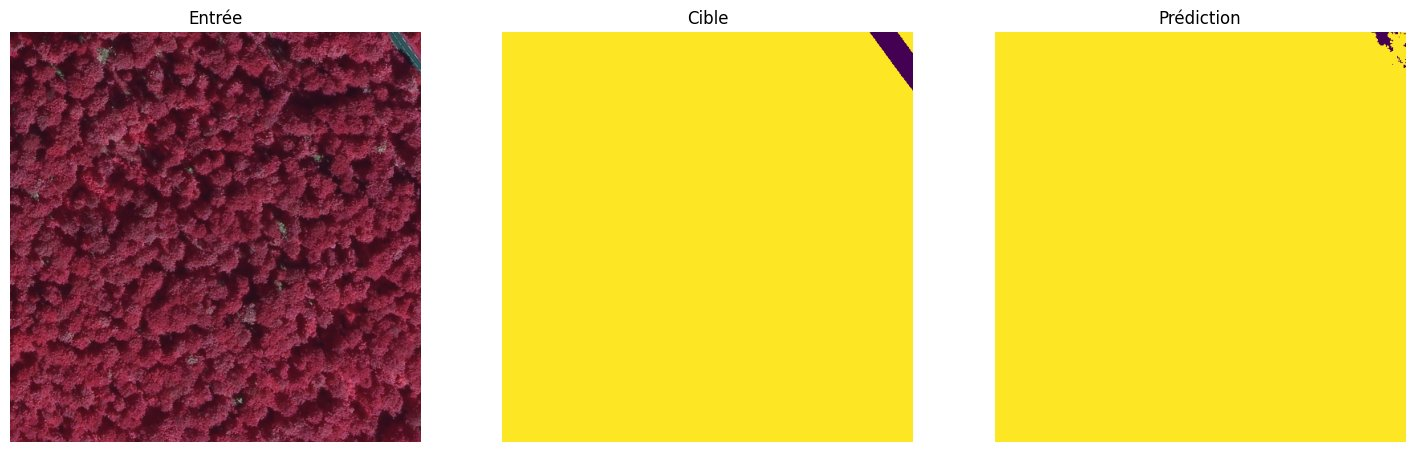

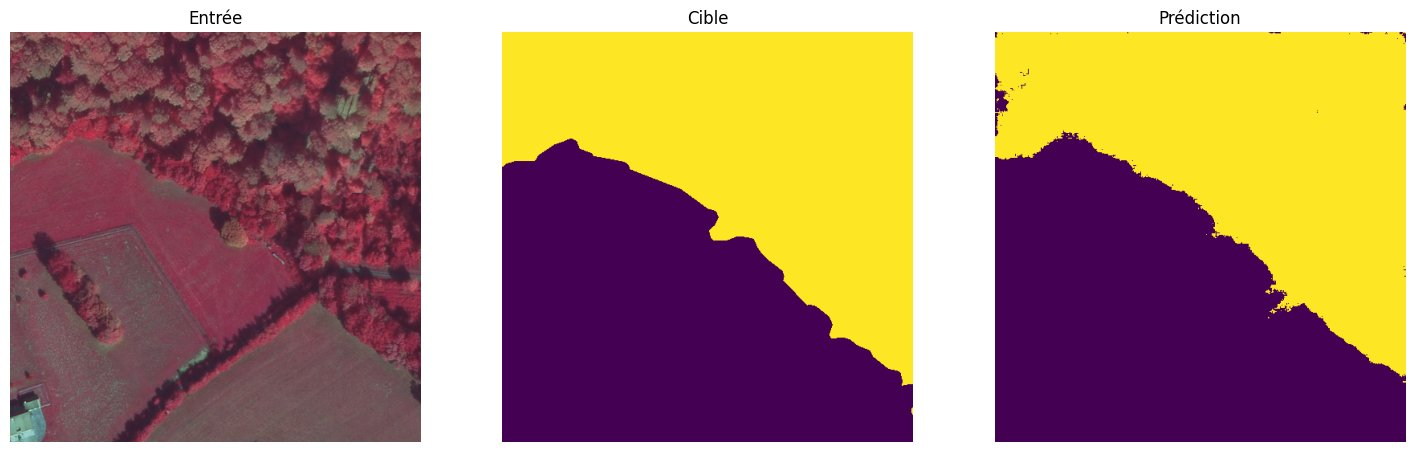

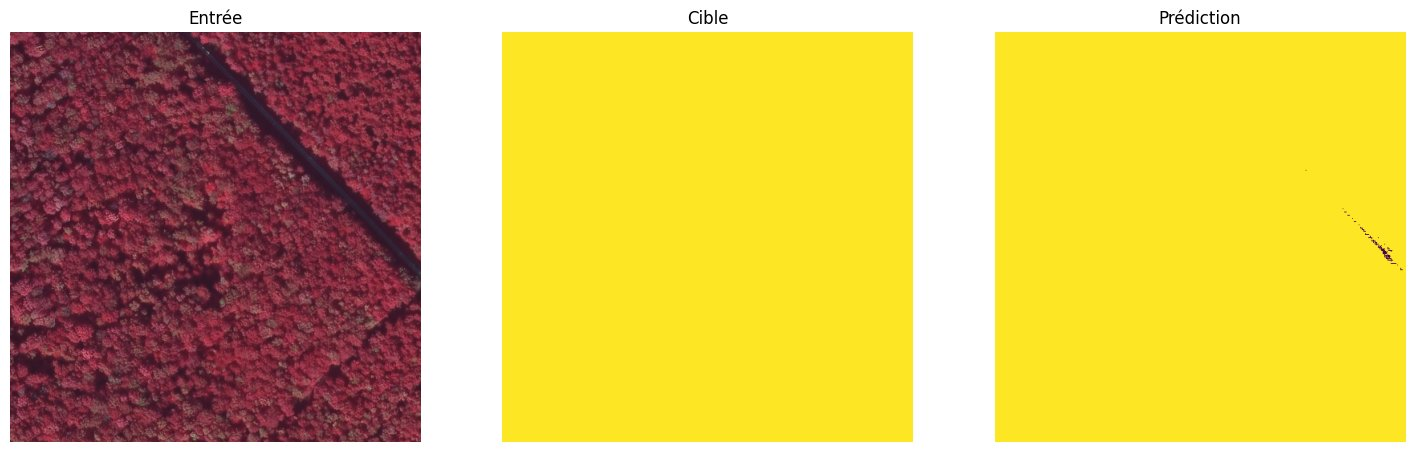

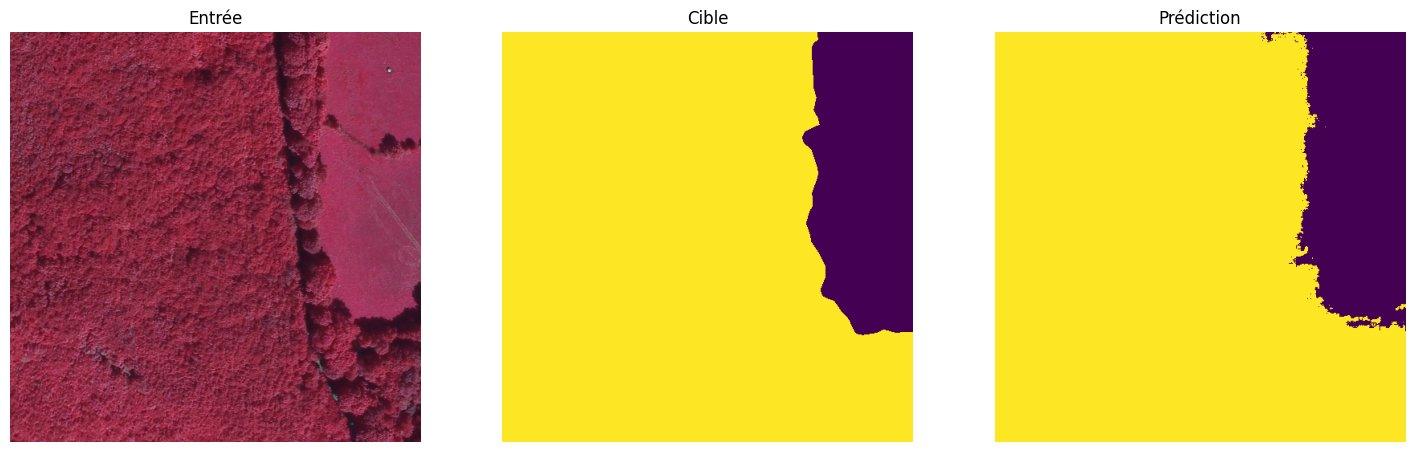

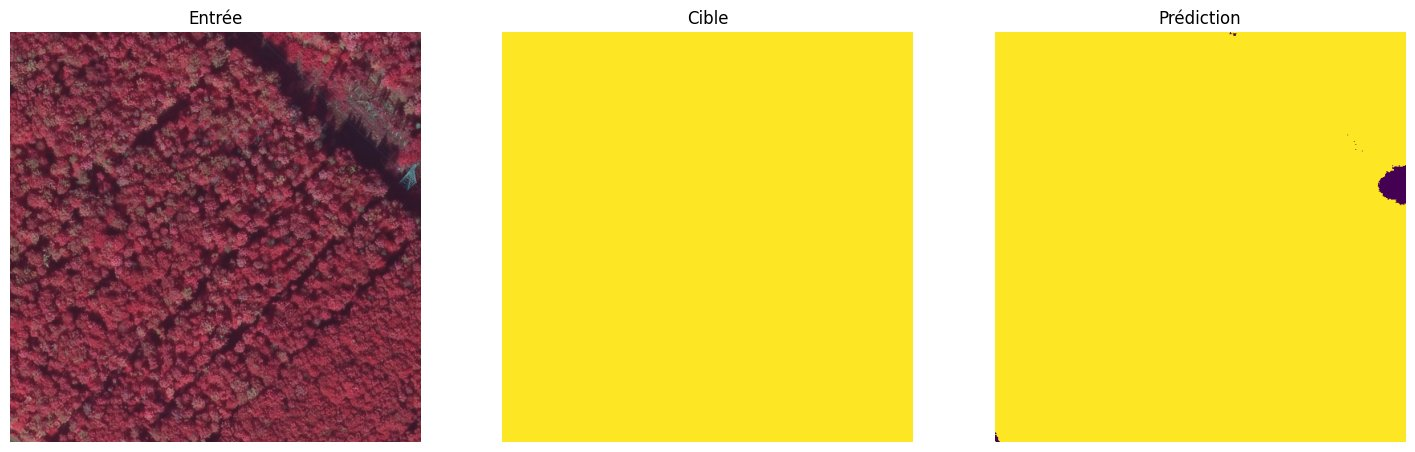

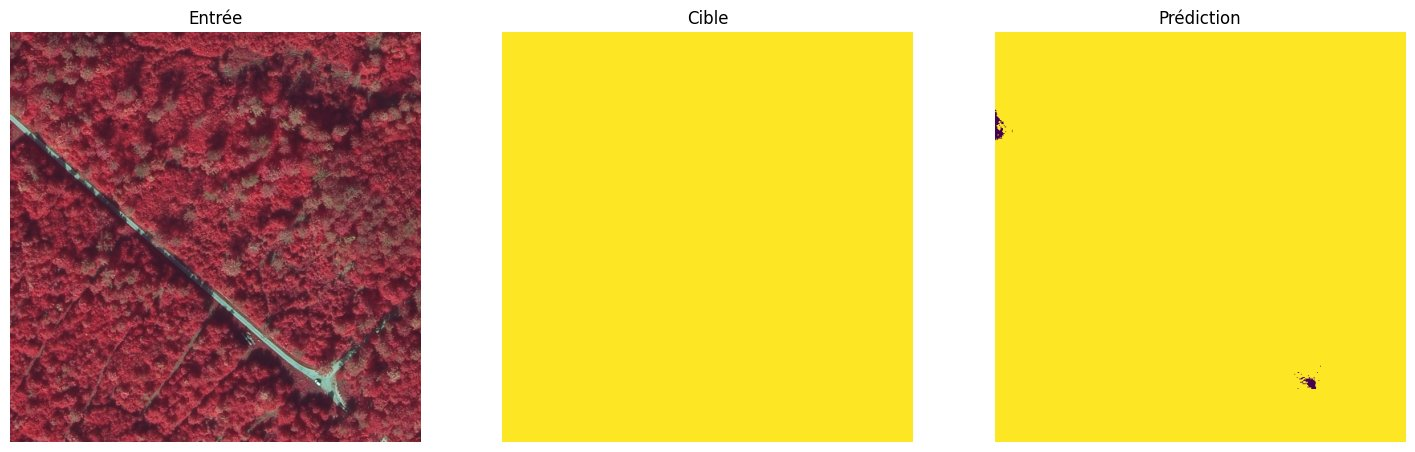

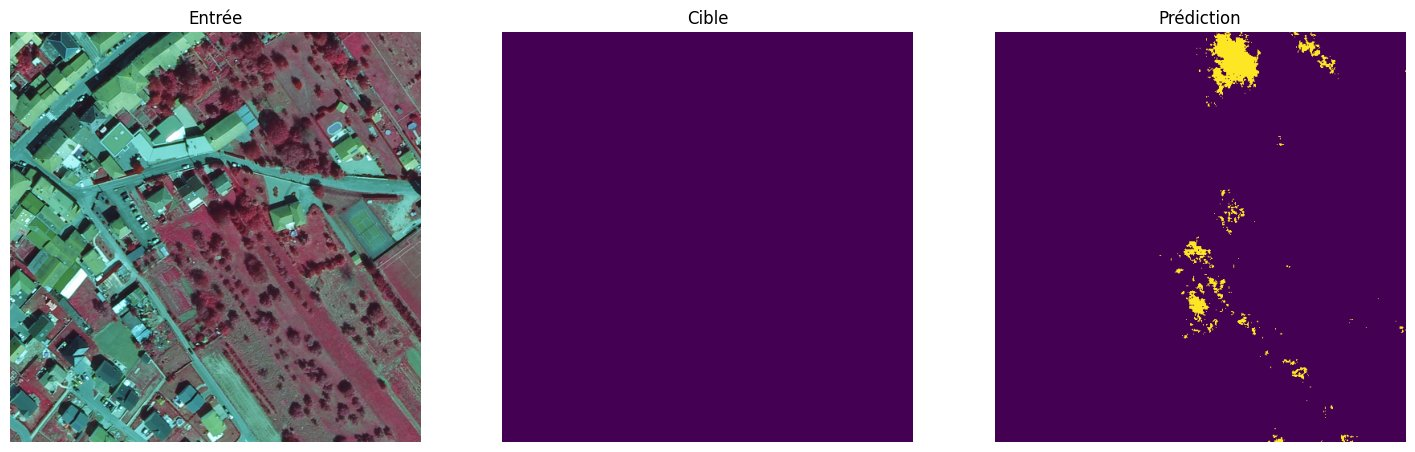

In [16]:
# Chargement du meilleur modèle
unet.load_weights("best_unet.weights.h5")

results["U-Net pré-entraîné (MobileNetV2)"] = unet.evaluate(
  test_generator, return_dict=True
)

# Les mêmes 8 tuiles de test que pour le premier modèle
preds = (unet.predict(X)[..., 0] > threshold).astype("uint8")

for x, y, p in zip(X, Y, preds):
  display_sample(x, y, p)

## Comparaison

Les scores des deux modèles sur les tuiles de test. Pour lire l'accuracy, comparez-la à la part de la classe la plus fréquente : un modèle qui répondrait toujours cette classe obtiendrait déjà cette accuracy, avec une IoU de la forêt nulle ou médiocre.

Avec la version complète, les deux modèles finissent proches. La version courte montre ce qu'apporte le pré-entraînement : après 3 epochs, lors de notre exécution, le premier modèle ne prédisait encore aucun pixel de forêt (IoU 0), quand le U-Net pré-entraîné atteignait déjà 0,97.

In [17]:
# Part des pixels de forêt dans les tuiles de test (recadrées)
forest_pixels = sum(
  float(tf.reduce_sum(test_generator[i][1])) for i in range(len(test_generator))
)
forest_share = forest_pixels / (len(df_test) * dim_input * dim_input)
print(f"Part de forêt : {forest_share:.1%}")
print(
  "Accuracy en répondant toujours la classe la plus fréquente :",
  f"{max(forest_share, 1 - forest_share):.1%}",
)

pandas.DataFrame(results).T[["accuracy", "iou"]].round(3)

Part de forêt : 61.5%
Accuracy en répondant toujours la classe la plus fréquente : 61.5%


,accuracy,iou
Encodeur-décodeur entraîné de zéro,0.977,0.964
U-Net pré-entraîné (MobileNetV2),0.981,0.970


## À retenir

- La segmentation sémantique classe chaque pixel : ici, forêt ou non-forêt, sur des photos aériennes en infrarouge couleur.
- L'accuracy compte surtout les pixels faciles, loin des lisières. L'IoU de la classe forêt juge la forme des zones prédites : c'est elle qu'il faut comparer.
- Les connexions transversales du U-Net rendent au décodeur les détails que l'encodeur a perdus en réduisant l'image.
- Un encodeur pré-entraîné sur ImageNet apporte des caractéristiques visuelles déjà apprises, même pour des images infrarouges qu'il n'a jamais vues : c'est l'apprentissage par transfert. Seul le décodeur reste à entraîner : quelques epochs lui suffisent, là où le modèle entraîné de zéro a besoin de bien plus pour le rattraper.
- Toutes les tuiles d'une zone restent dans le même ensemble (entraînement, validation ou test) : sinon, des tuiles voisines presque identiques feraient surestimer les scores.